<a href="https://colab.research.google.com/github/cs23f012-web/CSL701-20-Machine-Learning-Lab/blob/main/CS20exp5ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Apurva Santosh Jadhav
roll no: CS20

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# Define column names based on dataset documentation
column_names = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Direct URL to raw dataset file
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Load dataset into Pandas DataFrame
df = pd.read_csv(url, header=None, names=column_names)

# 1. Print first five records
print("--- First 5 Records ---")
print(df.head())
print("\n" + "="*50 + "\n")

# 2. Print dataset shape
print("--- Dataset Shape ---")
print(f"Shape: {df.shape}")
print("\n" + "="*50 + "\n")

# 3. Print data types of all features
print("--- Data Types ---")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# 4. Print descriptive statistics of numeric features
print("--- Descriptive Statistics ---")
print(df.describe())

--- First 5 Records ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


--- Dataset Shape ---
Shape: (768, 9)


--- Data Types ---
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
Di

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

--- Class Balance ---
Non-Diabetic (0): 500 (65.10%)
Diabetic     (1): 268 (34.90%)



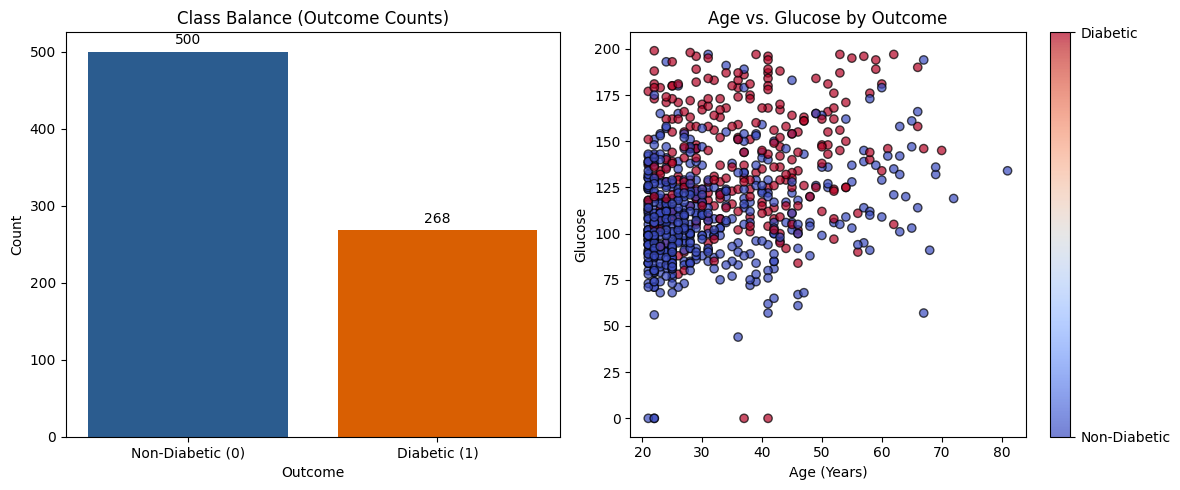

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate absolute count and percentage of Outcome classes
counts = df['Outcome'].value_counts()
percentages = df['Outcome'].value_counts(normalize=True) * 100

print("--- Class Balance ---")
print(f"Non-Diabetic (0): {counts[0]} ({percentages[0]:.2f}%)")
print(f"Diabetic     (1): {counts[1]} ({percentages[1]:.2f}%)\n")

# Plot Class Balance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(['Non-Diabetic (0)', 'Diabetic (1)'], counts, color=['#2b5c8f', '#d95f02'])
plt.title('Class Balance (Outcome Counts)')
plt.xlabel('Outcome')
plt.ylabel('Count')

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom')

# 2. Scatter Plot: Age vs. Glucose color-coded by Outcome
plt.subplot(1, 2, 2)
scatter = plt.scatter(df['Age'], df['Glucose'], c=df['Outcome'], cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title('Age vs. Glucose by Outcome')
plt.xlabel('Age (Years)')
plt.ylabel('Glucose')
cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(['Non-Diabetic', 'Diabetic'])

plt.tight_layout()
plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
import pandas as pd
import numpy as np

# List of features where 0 is physically impossible
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 1. Replace 0 with NaN for these features
df[zero_invalid_cols] = df[zero_invalid_cols].replace(0, np.nan)

# Display count of missing values per column
print("--- Missing Values Count per Feature ---")
print(df[zero_invalid_cols].isnull().sum())
print("\n" + "="*50 + "\n")

# 2. Impute missing values using the median of each feature
# (Median is preferred over mean because distributions are skewed by extreme outliers)
df[zero_invalid_cols] = df[zero_invalid_cols].fillna(df[zero_invalid_cols].median())

# Verify that all missing values have been handled
print("--- Remaining Missing Values After Imputation ---")
print(df[zero_invalid_cols].isnull().sum())

--- Missing Values Count per Feature ---
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


--- Remaining Missing Values After Imputation ---
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Isolate the feature matrix (X) and target vector (y)
X = df.iloc[:, :8]  # First 8 columns (Pregnancies through Age)
y = df.iloc[:, 8]   # 9th column (Outcome)

# 2. Split dataset into 80% Training and 20% Test using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Verify shapes and class distributions
print("--- Dataset Split Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}\n")

print("--- Class Distribution Preservation ---")
print("Original dataset proportions:\n", y.value_counts(normalize=True).round(4).to_dict())
print("Training set proportions:\n", y_train.value_counts(normalize=True).round(4).to_dict())
print("Test set proportions:\n", y_test.value_counts(normalize=True).round(4).to_dict())

--- Dataset Split Shapes ---
X_train shape: (614, 8)
X_test shape:  (154, 8)
y_train shape: (614,)
y_test shape:  (154,)

--- Class Distribution Preservation ---
Original dataset proportions:
 {0: 0.651, 1: 0.349}
Training set proportions:
 {0: 0.6515, 1: 0.3485}
Test set proportions:
 {0: 0.6494, 1: 0.3506}


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
import numpy as np
import pandas as pd

def get_bootstrap_sample(X, y, random_state=None):
    """
    Generates a bootstrap sample (sampling with replacement)
    from the input feature matrix X and target vector y.
    """
    if random_state is not None:
        np.random.seed(random_state)

    n_samples = X.shape[0]

    # Generate random indices with replacement
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)

    # Extract bootstrap sample using indexing
    if isinstance(X, (pd.DataFrame, pd.Series)):
        X_bs = X.iloc[bootstrap_indices]
        y_bs = y.iloc[bootstrap_indices]
    else:
        X_bs = X[bootstrap_indices]
        y_bs = y[bootstrap_indices]

    return X_bs, y_bs, bootstrap_indices

# --- Verification ---
X_bs, y_bs, bs_indices = get_bootstrap_sample(X_train, y_train, random_state=42)

n_samples = len(y_train)
unique_indices = np.unique(bs_indices)
num_unique = len(unique_indices)
num_duplicates = n_samples - num_unique

# Out-of-Bag (OOB) indices are those not selected in the bootstrap sample
all_indices = np.arange(n_samples)
oob_indices = np.setdiff1d(all_indices, bs_indices)

print("--- Bootstrap Verification ---")
print(f"Total training samples (N) : {n_samples}")
print(f"Bootstrap sample size      : {len(X_bs)}")
print(f"Unique samples selected    : {num_unique}")
print(f"Duplicate row count        : {num_duplicates}")
print(f"Out-of-Bag (OOB) count     : {len(oob_indices)} ({len(oob_indices)/n_samples*100:.2f}%)")

print("\n--- Example Verification Details ---")
print(f"First 10 resampled indices : {bs_indices[:10].tolist()}")
print(f"First 10 OOB row indices   : {oob_indices[:10].tolist()}")

--- Bootstrap Verification ---
Total training samples (N) : 614
Bootstrap sample size      : 614
Unique samples selected    : 377
Duplicate row count        : 237
Out-of-Bag (OOB) count     : 237 (38.60%)

--- Example Verification Details ---
First 10 resampled indices : [102, 435, 270, 106, 71, 20, 121, 466, 214, 330]
First 10 OOB row indices   : [2, 3, 5, 6, 10, 12, 23, 25, 29, 30]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize parameters
B = 50  # Number of bootstrap iterations (trees in ensemble)
ensemble = []

# Set a master seed for reproducibility across iterations
np.random.seed(42)

# 2. Train B decision trees on bootstrap samples
for b in range(B):
    # Generate a unique bootstrap sample using the Task 5 function
    X_bs, y_bs, _ = get_bootstrap_sample(X_train, y_train)

    # Instantiate a fully-grown DecisionTreeClassifier (high-variance base learner)
    tree = DecisionTreeClassifier(max_depth=None, random_state=b)

    # Fit model on the bootstrapped training subset
    tree.fit(X_bs, y_bs)

    # Append trained model to ensemble
    ensemble.append(tree)

# 3. Verification
print("--- Ensemble Training Summary ---")
print(f"Total base models trained: {len(ensemble)}")
print(f"Base learner type        : {type(ensemble[0]).__name__}")
print(f"Sample tree max_depth    : {ensemble[0].tree_.max_depth}")

--- Ensemble Training Summary ---
Total base models trained: 50
Base learner type        : DecisionTreeClassifier
Sample tree max_depth    : 14


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
import numpy as np

def custom_bagging_predict(ensemble, X_test):
    """
    Generates majority-voted predictions across all base models in the ensemble.

    Parameters:
    - ensemble: list of trained base models (e.g., DecisionTreeClassifiers)
    - X_test: test dataset features

    Returns:
    - final_predictions: 1D numpy array containing the majority class (0 or 1) for each sample
    """
    # 1. Collect predictions from each model in the ensemble
    # Shape of all_preds: (B, N_test)
    all_preds = np.array([model.predict(X_test) for model in ensemble])

    # 2. Transpose to shape (N_test, B) so each row contains B votes for a single test sample
    all_preds = all_preds.T

    # 3. Apply Majority Voting
    # Sum the votes along axis=1 (since classes are 0 and 1, sum > B/2 means class 1 wins)
    vote_counts = np.sum(all_preds, axis=1)

    # Select class 1 if it receives more than half the votes, else class 0
    final_predictions = (vote_counts > (len(ensemble) / 2)).astype(int)

    return final_predictions

# --- Verification ---
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

print("--- Majority Voting Predictions Summary ---")
print(f"Total test samples predicted : {len(y_pred_bagging)}")
print(f"Predicted class distribution  : {np.bincount(y_pred_bagging)}")
print(f"First 10 predictions          : {y_pred_bagging[:10]}")

--- Majority Voting Predictions Summary ---
Total test samples predicted : 154
Predicted class distribution  : [112  42]
First 10 predictions          : [1 0 0 0 0 0 0 1 0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 1. Train a standalone single DecisionTreeClassifier (fully grown)
single_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree.fit(X_train, y_train)

# 2. Predict classes on X_test for both models
y_pred_single = single_tree.predict(X_test)
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

# 3. Function to compute and format evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        'Model': model_name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}"
    }, cm

# 4. Generate metrics and confusion matrices
metrics_single, cm_single = evaluate_model(y_test, y_pred_single, "Single Decision Tree")
metrics_bagging, cm_bagging = evaluate_model(y_test, y_pred_bagging, "Custom Bagging Ensemble")

# 5. Display Confusion Matrices
print("--- Confusion Matrix: Single Decision Tree ---")
print(cm_single)
print("\n--- Confusion Matrix: Custom Bagging Ensemble ---")
print(cm_bagging)
print("\n" + "="*55 + "\n")

# 6. Display Comparison Table
results_df = pd.DataFrame([metrics_single, metrics_bagging])
print("--- Performance Comparison ---")
print(results_df.to_string(index=False))

--- Confusion Matrix: Single Decision Tree ---
[[79 21]
 [28 26]]

--- Confusion Matrix: Custom Bagging Ensemble ---
[[86 14]
 [26 28]]


--- Performance Comparison ---
                  Model Accuracy Precision Recall F1-Score
   Single Decision Tree   0.6818    0.5532 0.4815   0.5149
Custom Bagging Ensemble   0.7403    0.6667 0.5185   0.5833


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

--- ROC-AUC Comparison ---
Single Decision Tree AUC : 0.6357
Custom Bagging Ensemble AUC: 0.8053
Absolute AUC Improvement  : +0.1695


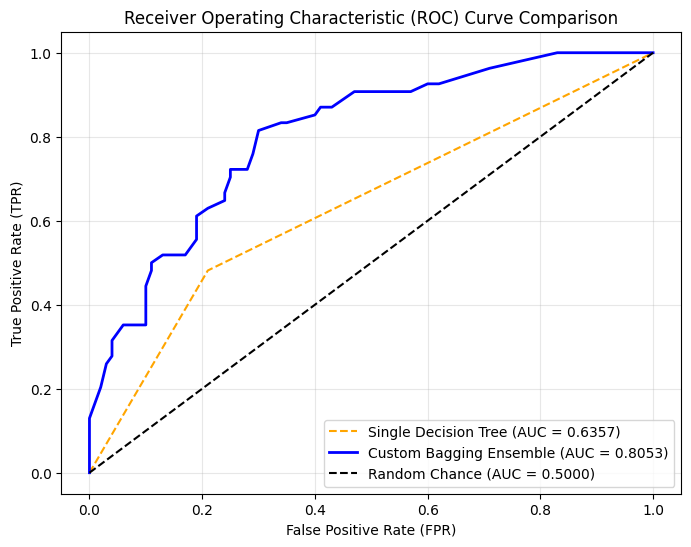

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate predicted probabilities for both models

# Single Decision Tree probabilities for positive class (class 1)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]

# Custom Bagging Ensemble: average predicted probabilities across all base trees
all_tree_probs = np.array([tree.predict_proba(X_test)[:, 1] for tree in ensemble])
y_prob_bagging = np.mean(all_tree_probs, axis=0)

# 2. Calculate ROC curves and AUC scores
fpr_single, tpr_single, _ = roc_curve(y_test, y_prob_single)
auc_single = roc_auc_score(y_test, y_prob_single)

fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_prob_bagging)
auc_bagging = roc_auc_score(y_test, y_prob_bagging)

# Print AUC comparison
print("--- ROC-AUC Comparison ---")
print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Custom Bagging Ensemble AUC: {auc_bagging:.4f}")
print(f"Absolute AUC Improvement  : +{(auc_bagging - auc_single):.4f}")

# 3. Plot ROC curves on a single chart
plt.figure(figsize=(8, 6))

plt.plot(fpr_single, tpr_single, label=f'Single Decision Tree (AUC = {auc_single:.4f})', color='orange', linestyle='--')
plt.plot(fpr_bagging, tpr_bagging, label=f'Custom Bagging Ensemble (AUC = {auc_bagging:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)')

plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [ ]:
import pandas as pd
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Instantiate Scikit-Learn's built-in BaggingClassifier
sklearn_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
    n_estimators=50,
    random_state=42
)

# 2. Fit on training data and predict on test set
sklearn_bagging.fit(X_train, y_train)
y_pred_sklearn = sklearn_bagging.predict(X_test)

# 3. Evaluate Scikit-Learn BaggingClassifier
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)

# Evaluate Custom Bagging Model (from Task 7 and Task 8)
acc_custom = accuracy_score(y_test, y_pred_bagging)
cm_custom = confusion_matrix(y_test, y_pred_bagging)

# 4. Display Confusion Matrices
print("--- Confusion Matrix: Custom Bagging Classifier ---")
print(cm_custom)

print("\n--- Confusion Matrix: Scikit-Learn BaggingClassifier ---")
print(cm_sklearn)
print("\n" + "="*55 + "\n")

# 5. Display Comparison Summary
comparison_df = pd.DataFrame([
    {"Model": "Custom Bagging Ensemble", "Test Accuracy": f"{acc_custom:.4f}"},
    {"Model": "Scikit-Learn BaggingClassifier", "Test Accuracy": f"{acc_sklearn:.4f}"}
])

print("--- Validation Summary ---")
print(comparison_df.to_string(index=False))

--- Confusion Matrix: Custom Bagging Classifier ---
[[86 14]
 [26 28]]

--- Confusion Matrix: Scikit-Learn BaggingClassifier ---
[[85 15]
 [26 28]]


--- Validation Summary ---
                         Model Test Accuracy
       Custom Bagging Ensemble        0.7403
Scikit-Learn BaggingClassifier        0.7338


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?